# HW 9: Boosting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
import xgboost as xgb

In [2]:
%load_ext pycodestyle_magic

In [13]:
def roc_curve_plot(X, y, clf0, clf1):

    # Default classifier
    classifier = clf0
    cv = StratifiedKFold(n_splits=6)
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    i = 0

    for train, test in cv.split(X, y):
        probas_ = classifier.fit(X[train], y[train]).predict_proba(X[test])
        # Compute ROC curve and area the curve
        fpr, tpr, thresholds = roc_curve(y[test], probas_[:, 1])
        tprs.append(interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

        i += 1

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)

    plt.figure(figsize=(7.5, 7.5))
    plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', alpha=.8)

    plt.plot(mean_fpr, mean_tpr, color='b',
             label=r'Default Mean ROC (AUC = %0.2f $\pm$ %0.2f)'
             % (mean_auc, std_auc),
             lw=2, alpha=.8)

    # Tuned classifier
    classifier = clf1
    cv = StratifiedKFold(n_splits=6)
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    i = 0
    for train, test in cv.split(X, y):
        probas_ = classifier.fit(X[train], y[train]).predict_proba(X[test])
        # Compute ROC curve and area the curve
        fpr, tpr, thresholds = roc_curve(y[test], probas_[:, 1])
        tprs.append(interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

        i += 1

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)

    plt.plot(mean_fpr, mean_tpr, color='orange',
             label=r'Tuned Mean ROC (AUC = %0.2f $\pm$ %0.2f)'
             % (mean_auc, std_auc),
             lw=2, alpha=.8)

    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC')
    plt.legend(loc="lower right")
    plt.show()

## Import data

In [14]:
df = pd.read_csv('data/train.csv')

In [15]:
descr = pd.read_excel('data/description.xlsx')

### Columns description

In [16]:
descr[['Variable Name','Description']]

,Variable Name,Description
0,UniqueID,Identifier for customers
1,loan_default,Payment default in the first EMI on due date
2,disbursed_amount,Amount of Loan disbursed
3,asset_cost,Cost of the Asset
4,ltv,Loan to Value of the asset
5,branch_id,Branch where the loan was disbursed
6,supplier_id,Vehicle Dealer where the loan was disbursed
7,manufacturer_id,"Vehicle manufacturer(Hero, Honda, TVS etc.)"
8,Current_pincode,Current pincode of the customer
9,Date.of.Birth,Date of birth of the customer


In [17]:
df.head()

,UniqueID,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Date.of.Birth,Employment.Type,...,SEC.SANCTIONED.AMOUNT,SEC.DISBURSED.AMOUNT,PRIMARY.INSTAL.AMT,SEC.INSTAL.AMT,NEW.ACCTS.IN.LAST.SIX.MONTHS,DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS,AVERAGE.ACCT.AGE,CREDIT.HISTORY.LENGTH,NO.OF_INQUIRIES,loan_default
0,750296,42996,69150,63.60,18,22708,86,2728,31-12-88,Salaried,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
1,652580,37941,45536,84.68,5,13942,51,3425,01-01-78,Self employed,...,0,0,6298,0,1,0,0yrs 10mon,1yrs 5mon,0,0
2,697940,48651,65138,76.76,61,15897,45,1377,01-01-64,Salaried,...,0,0,100000,0,0,0,0yrs 8mon,1yrs 1mon,0,0
3,703152,60215,72684,83.88,136,17783,86,3708,10-08-98,NaN,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
4,603556,59615,72086,84.89,19,16938,86,1853,30-01-85,Self employed,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0


## Categorical features

In [18]:
df.dtypes[df.dtypes == 'object']

Date.of.Birth                    object
Employment.Type                  object
DisbursalDate                    object
PERFORM_CNS.SCORE.DESCRIPTION    object
AVERAGE.ACCT.AGE                 object
CREDIT.HISTORY.LENGTH            object
dtype: object

### Dealing with the customer age

In [19]:
df['Date.of.Birth'].head()

0    31-12-88
1    01-01-78
2    01-01-64
3    10-08-98
4    30-01-85
Name: Date.of.Birth, dtype: object

In [20]:
df['birth_year'] = (df['Date.of.Birth'].str.split('-').str[-1]).astype(int)
df['birth_year'] = (df['birth_year'] > 40) * (df['birth_year'] + 1900) +\
    (df['birth_year'] < 40) * (df['birth_year'] + 2000)
df['disb_year'] = (df['DisbursalDate'].str.split('-').str[-1]).astype(int)
df['disb_year'] = (df['disb_year'] > 40) * (df['disb_year'] + 1900) +\
    (df['disb_year'] < 40) * (df['disb_year'] + 2000)
df['customer_age'] = df['disb_year'] - df['birth_year']

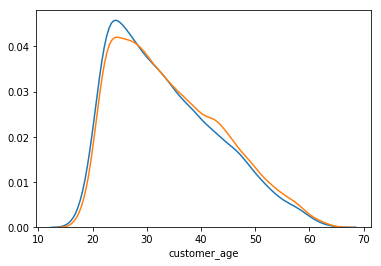

In [21]:
sns.distplot(df.loc[df['loan_default']==1, 'customer_age'],
             hist=False)
sns.distplot(df.loc[df['loan_default']==0, 'customer_age'],
             hist=False)

In [22]:
df = df.drop(['Date.of.Birth', 'DisbursalDate',
              'birth_year', 'disb_year'], axis=1)

### Employment

In [23]:
df['Employment.Type'].unique()

array(['Salaried', 'Self employed', nan], dtype=object)

In [24]:
df['Employment.Type'].value_counts(dropna=False)

Self employed    12761
Salaried          9757
NaN                797
Name: Employment.Type, dtype: int64

In [25]:
df['Employment.Type'] = (df['Employment.Type'] == 'Salaried').astype(int)

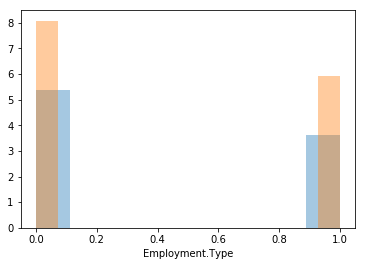

In [26]:
sns.distplot(df.loc[df['loan_default'] == 1, 'Employment.Type'],
             kde=False, norm_hist=True)
sns.distplot(df.loc[df['loan_default'] == 0, 'Employment.Type'],
             kde=False, norm_hist=True)

### PERFORM_CNS.SCORE.DESCRIPTION

In [27]:
df['PERFORM_CNS.SCORE.DESCRIPTION'].value_counts()

No Bureau History Available                                11685
C-Very Low Risk                                             1606
A-Very Low Risk                                             1416
D-Very Low Risk                                             1099
B-Very Low Risk                                              914
K-High Risk                                                  861
M-Very High Risk                                             849
F-Low Risk                                                   833
H-Medium Risk                                                684
E-Low Risk                                                   613
I-Medium Risk                                                567
G-Low Risk                                                   388
J-High Risk                                                  386
Not Scored: Not Enough Info available on the customer        379
Not Scored: Sufficient History Not Available                 378
Not Scored: No Activity s

In [28]:
df.loc[df['PERFORM_CNS.SCORE.DESCRIPTION']
       .str.contains('|'.join(['Not Scored', 'No Bureau'])),
       'PERFORM_CNS.SCORE.DESCRIPTION'] = ''

In [29]:
df['PERFORM_CNS.SCORE'].head()

0      0
1    763
2    845
3      0
4      0
Name: PERFORM_CNS.SCORE, dtype: int64

In [31]:
df['PERFORM_CNS.SCORE.DESCRIPTION'].head()

0                   
1    B-Very Low Risk
2    A-Very Low Risk
3                   
4                   
Name: PERFORM_CNS.SCORE.DESCRIPTION, dtype: object

In [32]:
riskvals = ['Very Low Risk', 'Low Risk',
            'Medium Risk', 'High Risk',
            'Very High Risk']
for r in riskvals:
    df[r] = df['PERFORM_CNS.SCORE.DESCRIPTION'].str.contains(r)

In [33]:
df.head()

,UniqueID,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Employment.Type,State_ID,...,AVERAGE.ACCT.AGE,CREDIT.HISTORY.LENGTH,NO.OF_INQUIRIES,loan_default,customer_age,Very Low Risk,Low Risk,Medium Risk,High Risk,Very High Risk
0,750296,42996,69150,63.60,18,22708,86,2728,1,4,...,0yrs 0mon,0yrs 0mon,0,0,30,False,False,False,False,False
1,652580,37941,45536,84.68,5,13942,51,3425,0,9,...,0yrs 10mon,1yrs 5mon,0,0,40,True,True,False,False,False
2,697940,48651,65138,76.76,61,15897,45,1377,1,6,...,0yrs 8mon,1yrs 1mon,0,0,54,True,True,False,False,False
3,703152,60215,72684,83.88,136,17783,86,3708,0,8,...,0yrs 0mon,0yrs 0mon,0,0,20,False,False,False,False,False
4,603556,59615,72086,84.89,19,16938,86,1853,0,4,...,0yrs 0mon,0yrs 0mon,0,0,33,False,False,False,False,False


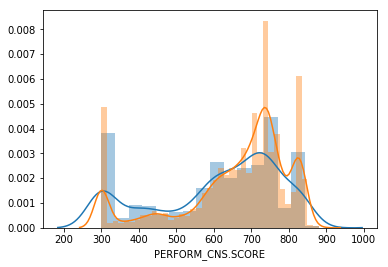

In [34]:
sns.distplot(df.loc[(df['loan_default'] == 1) &
                    (df['PERFORM_CNS.SCORE'] > 200),
                    'PERFORM_CNS.SCORE'], norm_hist=True)
sns.distplot(df.loc[(df['loan_default'] == 0) &
                    (df['PERFORM_CNS.SCORE'] > 200),
                    'PERFORM_CNS.SCORE'], norm_hist=True)

### AVERAGE.ACCT.AGE 

In [35]:
df['account_months'] = (df['AVERAGE.ACCT.AGE']
                        .str.split('yrs').str[0]).astype(int) * 12 + \
    df['AVERAGE.ACCT.AGE'].str.split('yrs').str[1].str.split('mon')\
    .str[0].astype(int)

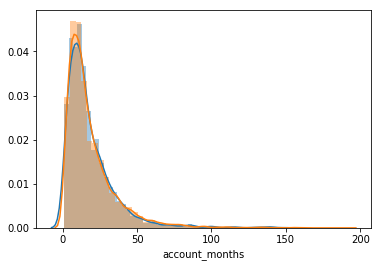

In [36]:
sns.distplot(df.loc[(df['loan_default'] == 1) &
                    (df['account_months'] != 0),
                    'account_months'])
sns.distplot(df.loc[(df['loan_default'] == 0) &
                    (df['account_months']!=0),
                    'account_months'])

Checking the percentages of the defaulted customers among
the ones with zero account age

In [37]:
df.loc[(df['loan_default'] == 1) & (df['account_months'] != 0),
       'account_months'].shape[0]/\
    df.loc[(df['account_months'] != 0),
           'account_months'].shape[0]

0.20121414745732888

In [38]:
df.loc[(df['loan_default'] == 1) & (df['account_months'] == 0),
       'account_months'].shape[0]/\
    df.loc[(df['account_months'] == 0),
           'account_months'].shape[0]

0.24027115239769017

Creating a separate feature for it

In [39]:
# turned out to not work
# df['account_months_0'] = (df['account_months'] == 0)

In [40]:
df = df.drop(['AVERAGE.ACCT.AGE'], axis=1)

### CREDIT.HISTORY.LENGTH

In [41]:
df['credit_months'] = (df['CREDIT.HISTORY.LENGTH'].str.split('yrs').str[0])\
    .astype(int)*12 + df['CREDIT.HISTORY.LENGTH'].str.split('yrs').str[1]\
    .str.split('mon').str[0].astype(int)

Checking for correlation with 'account_months'

In [42]:
np.corrcoef([df['credit_months'], df['account_months']])

array([[1.        , 0.82907514],
       [0.82907514, 1.        ]])

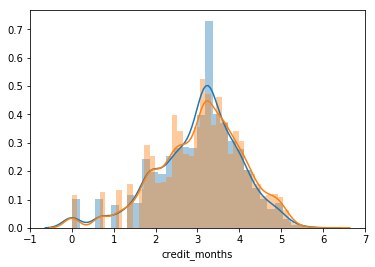

In [43]:
sns.distplot(np.log(df.loc[(df['credit_months'] > 0) &
                           (df['loan_default'] == 1),
                           'credit_months']))
sns.distplot(np.log(df.loc[(df['credit_months'] > 0) &
                           (df['loan_default'] == 0),
                           'credit_months']))

In [44]:
df = df.drop(df.dtypes[df.dtypes == 'object'].index,
             axis=1)

### Check for NaN

In [45]:
df.isna().sum()[df.isna().sum()!=0]

Series([], dtype: int64)

In [46]:
df.head()

,UniqueID,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Employment.Type,State_ID,...,NO.OF_INQUIRIES,loan_default,customer_age,Very Low Risk,Low Risk,Medium Risk,High Risk,Very High Risk,account_months,credit_months
0,750296,42996,69150,63.60,18,22708,86,2728,1,4,...,0,0,30,False,False,False,False,False,0,0
1,652580,37941,45536,84.68,5,13942,51,3425,0,9,...,0,0,40,True,True,False,False,False,10,17
2,697940,48651,65138,76.76,61,15897,45,1377,1,6,...,0,0,54,True,True,False,False,False,8,13
3,703152,60215,72684,83.88,136,17783,86,3708,0,8,...,0,0,20,False,False,False,False,False,0,0
4,603556,59615,72086,84.89,19,16938,86,1853,0,4,...,0,0,33,False,False,False,False,False,0,0


## EDA

Checking the ID columns

In [47]:
df['branch_id'].nunique()

82

In [48]:
df['supplier_id'].nunique()

2365

In [49]:
df['manufacturer_id'].nunique()

10

In [50]:
df['Current_pincode_ID'].nunique()

4249

In [51]:
df['State_ID'].nunique()

22

In [52]:
df['Employee_code_ID'].nunique()

2963

Seems ok to drop ones with a lot of unique vals

In [53]:
df = df.drop(['supplier_id','Current_pincode_ID',
              'Employee_code_ID'], axis=1)

All the others go to one-hot encoding

In [54]:
df = pd.get_dummies(df, columns=['manufacturer_id',
                                 'branch_id', 'State_ID'])

In [55]:
df.head()

,UniqueID,disbursed_amount,asset_cost,ltv,Employment.Type,MobileNo_Avl_Flag,Aadhar_flag,PAN_flag,VoterID_flag,Driving_flag,...,State_ID_13,State_ID_14,State_ID_15,State_ID_16,State_ID_17,State_ID_18,State_ID_19,State_ID_20,State_ID_21,State_ID_22
0,750296,42996,69150,63.60,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,652580,37941,45536,84.68,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,697940,48651,65138,76.76,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,703152,60215,72684,83.88,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,603556,59615,72086,84.89,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Checking some numerical features

In [56]:
num_cols = ['disbursed_amount', 'asset_cost',
            'ltv']

/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/statsmodels/nonparametric/kde.py:447: RuntimeWarning: invalid value encountered in greater
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two columns.
/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/statsmodels/nonparametric/kde.py:447: RuntimeWarning: invalid value encountered in less
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two columns.


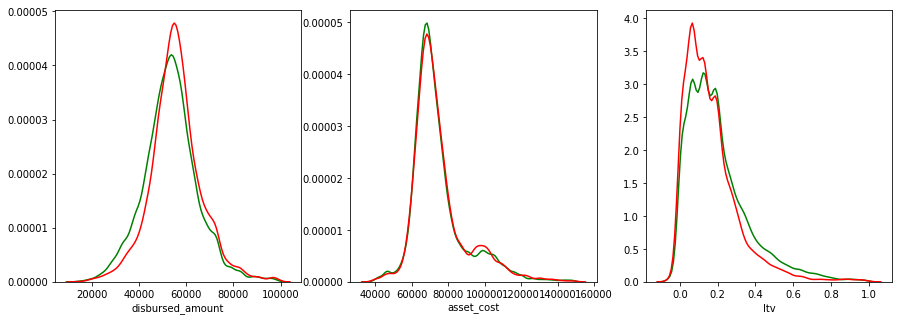

In [57]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
plot_data = df.copy()

plot_data = plot_data.loc[plot_data['disbursed_amount'] < 100000, :]
plot_data = plot_data.loc[plot_data['asset_cost'] < 150000, :]
plot_data['ltv'] = 4.5 - (np.log(plot_data['ltv']))
plot_data['ltv'] = plot_data.loc[plot_data['ltv'] < 1, 'ltv']

feature_names = [c for c in num_cols if c != 'loan_default']
for name, ax in zip(feature_names, axs.flatten()):
    sns.distplot(plot_data.loc[plot_data['loan_default'] == 0, name],
                 ax=ax, color='green', kde=True, hist=False)
    sns.distplot(plot_data.loc[plot_data['loan_default'] == 1, name],
                 ax=ax, color='red', kde=True, hist=False)

In [58]:
more_vals = ['PRI.NO.OF.ACCTS', 'PERFORM_CNS.SCORE',
             'PRI.ACTIVE.ACCTS', 'PRI.OVERDUE.ACCTS',
             'PRI.CURRENT.BALANCE', 'PRI.SANCTIONED.AMOUNT',
             'PRI.DISBURSED.AMOUNT', 'SEC.NO.OF.ACCTS',
             'SEC.ACTIVE.ACCTS', 'SEC.OVERDUE.ACCTS',
             'SEC.CURRENT.BALANCE', 'SEC.SANCTIONED.AMOUNT',
             'SEC.DISBURSED.AMOUNT', 'PRIMARY.INSTAL.AMT',
             'SEC.INSTAL.AMT', 'NEW.ACCTS.IN.LAST.SIX.MONTHS',
             'DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS', 'NO.OF_INQUIRIES']

/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/ipykernel_launcher.py:15: RuntimeWarning: divide by zero encountered in log
  from ipykernel import kernelapp as app
/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in log
  from ipykernel import kernelapp as app
/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/ipykernel_launcher.py:19: RuntimeWarning: invalid value encountered in log


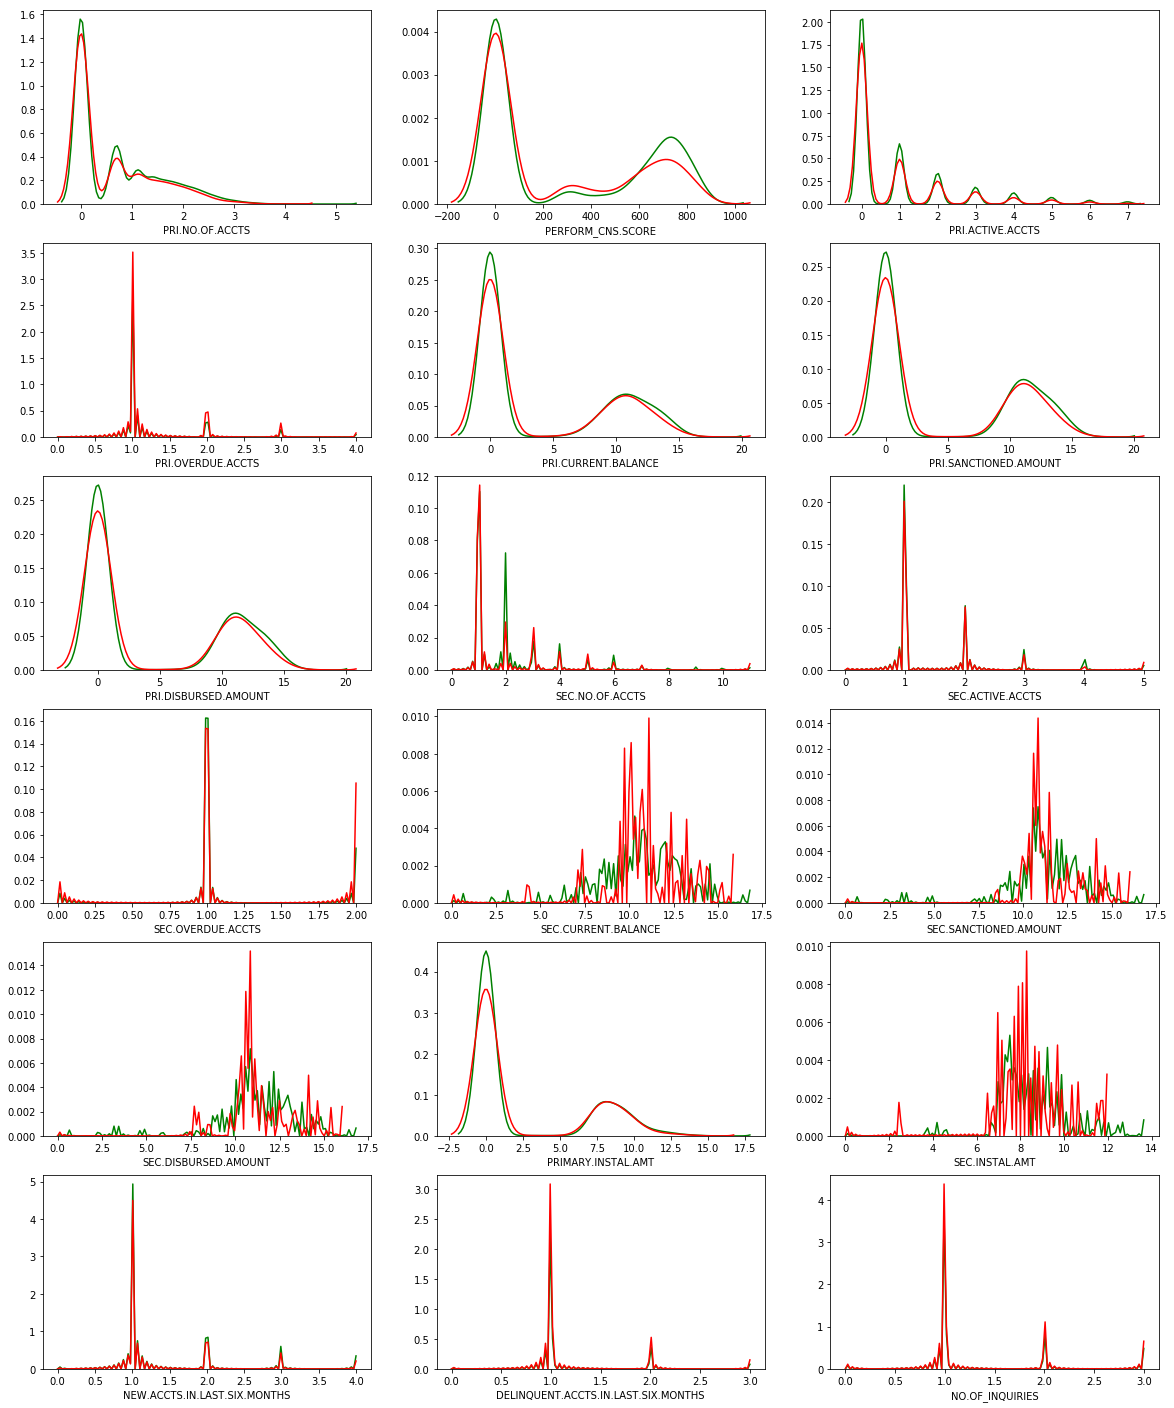

In [59]:
fig, axs = plt.subplots(6, 3, figsize=(20, 25))
plot_data = df.copy()

plot_data = plot_data.loc[plot_data['PRI.ACTIVE.ACCTS'] < 7.5, :]
plot_data = plot_data.loc[plot_data['PRI.OVERDUE.ACCTS'] < 5, :]
plot_data = plot_data.loc[plot_data['SEC.NO.OF.ACCTS'] < 12, :]
plot_data = plot_data.loc[plot_data['SEC.ACTIVE.ACCTS'] < 6, :]
plot_data = plot_data.loc[plot_data['SEC.OVERDUE.ACCTS'] < 3, :]
plot_data = plot_data.loc[plot_data['NEW.ACCTS.IN.LAST.SIX.MONTHS'] < 5, :]
plot_data = plot_data.loc[plot_data['DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS'] < 4,
                          :]
plot_data = plot_data.loc[plot_data['NO.OF_INQUIRIES'] < 4, :]

plot_data['PRI.NO.OF.ACCTS'] = np.log(plot_data['PRI.NO.OF.ACCTS']+1)
plot_data['PRI.CURRENT.BALANCE'] = np.log(plot_data['PRI.CURRENT.BALANCE']+1)
plot_data['PRI.SANCTIONED.AMOUNT'] = np.log(plot_data['PRI.SANCTIONED.AMOUNT']
                                            + 1)
plot_data['PRI.DISBURSED.AMOUNT'] = np.log(plot_data['PRI.DISBURSED.AMOUNT']+1)
plot_data['SEC.CURRENT.BALANCE'] = np.log(plot_data['SEC.CURRENT.BALANCE']+1)
plot_data['SEC.SANCTIONED.AMOUNT'] = np.log(plot_data['SEC.SANCTIONED.AMOUNT']
                                            + 1)
plot_data['SEC.DISBURSED.AMOUNT'] = np.log(plot_data['SEC.DISBURSED.AMOUNT']+1)
plot_data['PRIMARY.INSTAL.AMT'] = np.log(plot_data['PRIMARY.INSTAL.AMT']+1)
plot_data['SEC.INSTAL.AMT'] = np.log(plot_data['SEC.INSTAL.AMT']+1)

feature_names = [c for c in more_vals if c != 'loan_default']
for name, ax in zip(feature_names, axs.flatten()):
    sns.distplot(plot_data.loc[plot_data['loan_default'] == 0, name],
                 ax=ax, color='green', kde=True, hist=False)
    sns.distplot(plot_data.loc[plot_data['loan_default'] == 1, name],
                 ax=ax, color='red', kde=True, hist=False)

In [60]:
def filter_data(df, istrain):
    plot_data = df.copy()

    plot_data = plot_data.drop(['SEC.CURRENT.BALANCE',
                                'SEC.SANCTIONED.AMOUNT',
                                'SEC.DISBURSED.AMOUNT',
                                'SEC.INSTAL.AMT'], axis=1)

    if istrain:
        plot_data = plot_data.loc[plot_data['disbursed_amount'] < 100000, :]
        plot_data = plot_data.loc[plot_data['asset_cost'] < 150000, :]

        plot_data = plot_data.loc[plot_data['PRI.ACTIVE.ACCTS'] < 7.5, :]
        plot_data = plot_data.loc[plot_data['PRI.OVERDUE.ACCTS'] < 5, :]
        plot_data = plot_data.loc[plot_data['SEC.NO.OF.ACCTS'] < 12, :]
        plot_data = plot_data.loc[plot_data['SEC.ACTIVE.ACCTS'] < 6, :]
        plot_data = plot_data.loc[plot_data['SEC.OVERDUE.ACCTS'] < 3, :]
        plot_data = plot_data.loc[plot_data['NEW.ACCTS.IN.LAST.SIX.MONTHS']
                                  < 5, :]
        plot_data = \
            plot_data.loc[plot_data['DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS']
                          < 4, :]
        plot_data = plot_data.loc[plot_data['NO.OF_INQUIRIES'] < 4, :]

    plot_data['PRI.NO.OF.ACCTS'] = np.log(plot_data['PRI.NO.OF.ACCTS'] + 1)
    plot_data.loc[df['PRI.CURRENT.BALANCE'] < 0, 'PRI.CURRENT.BALANCE'] = 0

    plot_data['PRI.CURRENT.BALANCE'] = np.log(plot_data['PRI.CURRENT.BALANCE']
                                              + 1)

    plot_data['PRI.SANCTIONED.AMOUNT'] = \
        np.log(plot_data['PRI.SANCTIONED.AMOUNT'] + 1)
    plot_data['PRI.DISBURSED.AMOUNT'] = \
        np.log(plot_data['PRI.DISBURSED.AMOUNT'] + 1)
    plot_data['PRIMARY.INSTAL.AMT'] = \
        np.log(plot_data['PRIMARY.INSTAL.AMT'] + 1)

    return plot_data

In [61]:
filtered_df = filter_data(df, istrain=True)

In [62]:
filtered_df.shape

(22368, 148)

## Model

### xgboost with default parameters

In [63]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,\
    cross_val_score, GridSearchCV, RandomizedSearchCV

feature_cols = filtered_df.columns[(filtered_df.columns !=
                                    'loan_default') &
                                   (filtered_df.columns!='UniqueID')]

X_train, X_test, y_train, y_test = train_test_split(
    filtered_df.loc[: ,feature_cols], 
    filtered_df['loan_default'], 
    test_size=0.3, random_state=42)

In [64]:
xgb_model = xgb.XGBClassifier(n_jobs=-1).fit(X_train, y_train)

print("XGBClassifier accuracy: %.3f" % xgb_model.score(X_test, y_test))

XGBClassifier accuracy: 0.787


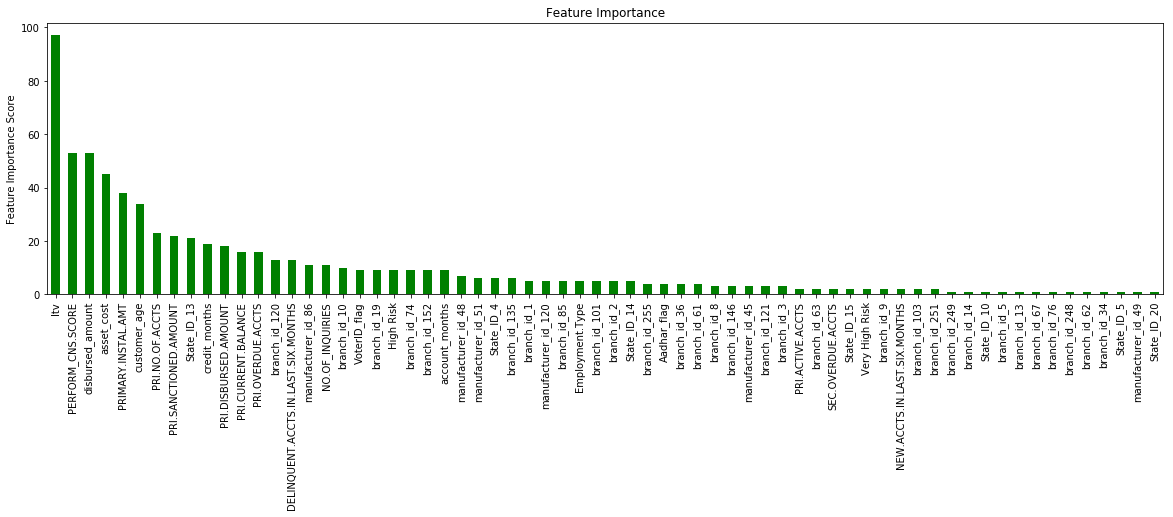

In [65]:
feat_imp = pd.Series(xgb_model.get_booster()
                     .get_score(importance_type='weight'))\
    .sort_values(ascending=False)
plt.figure(figsize=(20,5))
feat_imp.plot(kind='bar', title='Feature Importance', color='g')
plt.ylabel('Feature Importance Score')
plt.show()

In [66]:
score = cross_val_score(xgb_model, X_train, y_train,
                        scoring='roc_auc', cv=5)
print(score)
print(f'mean: {score.mean()}')
print(f'std: {score.std()}')

[0.62953142 0.63555102 0.65271495 0.63024254 0.6497128 ]
mean: 0.6395505468165393
std: 0.009793783124234163


### GridSearchCV

In [68]:
xgb_model = xgb.XGBClassifier()
xgb_grid = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions={"learning_rate" : [0.1],
                         "max_depth": np.arange(3, 8, 1),
                         "min_child_weight": np.arange(5, 15, 1),
                         "gamma": np.arange(0, 0.3, 0.025),
                         "colsample_bytree": np.arange(0.3, 0.8, 0.05),
                         "subsample": np.arange(0.7, 1, 0.025),
                         "n_estimators": [150]},
    scoring='roc_auc',
    cv=5,
    verbose=100,
    n_jobs=-1,
    n_iter=10
)
xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
Pickling array (shape=(146,), dtype=object).
Pickling array (shape=(15657,), dtype=int64).
Memmapping (shape=(21, 15657), dtype=int64) to new file /dev/shm/joblib_memmapping_folder_418_8494626683/418-140450138653976-d89a3e0062254829af778ca78e33256d.pkl
Pickling array (shape=(6, 15657), dtype=float64).
Pickling array (shape=(5, 15657), dtype=bool).
Memmapping (shape=(114, 15657), dtype=uint8) to new file /dev/shm/joblib_memmapping_folder_418_8494626683/418-140450138653976-e73e4baddaf940b0b5e6e2989f3629eb.pkl
Pickling array (shape=(21,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(5,), dtype=object).
Pickling array (shape=(114,), dtype=object).
Pickling array (shape=(21,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(15657,), dtype=int64).
Pickling array (shape=(15657,), dtype=int64)

[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    7.4s
Pickling array (shape=(146,), dtype=object).
Pickling array (shape=(15657,), dtype=int64).
Memmapping (shape=(21, 15657), dtype=int64) to old file /dev/shm/joblib_memmapping_folder_418_8494626683/418-140450138653976-d89a3e0062254829af778ca78e33256d.pkl
Pickling array (shape=(6, 15657), dtype=float64).
Pickling array (shape=(5, 15657), dtype=bool).
Memmapping (shape=(114, 15657), dtype=uint8) to old file /dev/shm/joblib_memmapping_folder_418_8494626683/418-140450138653976-e73e4baddaf940b0b5e6e2989f3629eb.pkl
Pickling array (shape=(21,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(5,), dtype=object).
Pickling array (shape=(114,), dtype=object).
Pickling array (shape=(21,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(15657,), dtype=int64).
Pickling array (shape=(15657,), dtype=int64).
Pickling array (shape=(15657,), dtype=int64).
Pickling array (shape=(1252

[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   18.1s
Pickling array (shape=(146,), dtype=object).
Pickling array (shape=(15657,), dtype=int64).
Memmapping (shape=(21, 15657), dtype=int64) to old file /dev/shm/joblib_memmapping_folder_418_8494626683/418-140450138653976-d89a3e0062254829af778ca78e33256d.pkl
Pickling array (shape=(6, 15657), dtype=float64).
Pickling array (shape=(5, 15657), dtype=bool).
Memmapping (shape=(114, 15657), dtype=uint8) to old file /dev/shm/joblib_memmapping_folder_418_8494626683/418-140450138653976-e73e4baddaf940b0b5e6e2989f3629eb.pkl
Pickling array (shape=(21,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(5,), dtype=object).
Pickling array (shape=(114,), dtype=object).
Pickling array (shape=(21,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(15657,), dtype=int64).
Pickling array (shape=(15657,), dtype=int64).
Pickling array (shape=(15657,), dtype=int64).
Pickling array (shape=(1252

[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   30.0s
Pickling array (shape=(146,), dtype=object).
Pickling array (shape=(15657,), dtype=int64).
Memmapping (shape=(21, 15657), dtype=int64) to old file /dev/shm/joblib_memmapping_folder_418_8494626683/418-140450138653976-d89a3e0062254829af778ca78e33256d.pkl
Pickling array (shape=(6, 15657), dtype=float64).
Pickling array (shape=(5, 15657), dtype=bool).
Memmapping (shape=(114, 15657), dtype=uint8) to old file /dev/shm/joblib_memmapping_folder_418_8494626683/418-140450138653976-e73e4baddaf940b0b5e6e2989f3629eb.pkl
Pickling array (shape=(21,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(5,), dtype=object).
Pickling array (shape=(114,), dtype=object).
Pickling array (shape=(21,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(15657,), dtype=int64).
Pickling array (shape=(15657,), dtype=int64).
Pickling array (shape=(15657,), dtype=int64).
Pickling array (shape=(1252

[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   39.6s
Pickling array (shape=(146,), dtype=object).
Pickling array (shape=(15657,), dtype=int64).
Memmapping (shape=(21, 15657), dtype=int64) to old file /dev/shm/joblib_memmapping_folder_418_8494626683/418-140450138653976-d89a3e0062254829af778ca78e33256d.pkl
Pickling array (shape=(6, 15657), dtype=float64).
Pickling array (shape=(5, 15657), dtype=bool).
Memmapping (shape=(114, 15657), dtype=uint8) to old file /dev/shm/joblib_memmapping_folder_418_8494626683/418-140450138653976-e73e4baddaf940b0b5e6e2989f3629eb.pkl
Pickling array (shape=(21,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(5,), dtype=object).
Pickling array (shape=(114,), dtype=object).
Pickling array (shape=(21,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(15657,), dtype=int64).
Pickling array (shape=(15657,), dtype=int64).
Pickling array (shape=(15657,), dtype=int64).
Pickling array (shape=(1252

[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:   53.8s
Pickling array (shape=(146,), dtype=object).
Pickling array (shape=(15657,), dtype=int64).
Memmapping (shape=(21, 15657), dtype=int64) to old file /dev/shm/joblib_memmapping_folder_418_8494626683/418-140450138653976-d89a3e0062254829af778ca78e33256d.pkl
Pickling array (shape=(6, 15657), dtype=float64).
Pickling array (shape=(5, 15657), dtype=bool).
Memmapping (shape=(114, 15657), dtype=uint8) to old file /dev/shm/joblib_memmapping_folder_418_8494626683/418-140450138653976-e73e4baddaf940b0b5e6e2989f3629eb.pkl
Pickling array (shape=(21,), dtype=object).
Pickling array (shape=(6,), dtype=object).
Pickling array (shape=(5,), dtype=object).
Pickling array (shape=(114,), dtype=object).
Pickling array (shape=(21,), dtype=int64).
Pickling array (shape=(6,), dtype=int64).
Pickling array (shape=(15657,), dtype=int64).
Pickling array (shape=(15657,), dtype=int64).
Pickling array (shape=(15657,), dtype=int64).
Pickling array (shape=(1252

[Parallel(n_jobs=-1)]: Done  42 out of  50 | elapsed:   59.7s remaining:   11.4s
[Parallel(n_jobs=-1)]: Done  43 out of  50 | elapsed:   59.9s remaining:    9.8s
[Parallel(n_jobs=-1)]: Done  44 out of  50 | elapsed:  1.0min remaining:    8.3s
[Parallel(n_jobs=-1)]: Done  45 out of  50 | elapsed:  1.1min remaining:    7.1s
[Parallel(n_jobs=-1)]: Done  46 out of  50 | elapsed:  1.1min remaining:    5.7s
[Parallel(n_jobs=-1)]: Done  47 out of  50 | elapsed:  1.1min remaining:    4.2s
[Parallel(n_jobs=-1)]: Done  48 out of  50 | elapsed:  1.1min remaining:    2.8s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  1.1min remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  1.1min finished


RandomizedSearchCV(cv=5, error_score='raise-deprecating',
                   estimator=XGBClassifier(base_score=0.5, booster='gbtree',
                                           colsample_bylevel=1,
                                           colsample_bynode=1,
                                           colsample_bytree=1, gamma=0,
                                           learning_rate=0.1, max_delta_step=0,
                                           max_depth=3, min_child_weight=1,
                                           missing=None, n_estimators=100,
                                           n_jobs=1, nthread=None,
                                           objective='binary:logistic',
                                           random_state=0, reg_alpha=0...
                                        'gamma': array([0.   , 0.025, 0.05 , 0.075, 0.1  , 0.125, 0.15 , 0.175, 0.2  ,
       0.225, 0.25 , 0.275]),
                                        'learning_rate': [0.1],
         

In [69]:
xgb_grid.best_params_

{'subsample': 0.8,
 'n_estimators': 150,
 'min_child_weight': 10,
 'max_depth': 3,
 'learning_rate': 0.1,
 'gamma': 0.17500000000000002,
 'colsample_bytree': 0.5499999999999999}

In [74]:
xgb_grid.best_score_

0.642593570992859

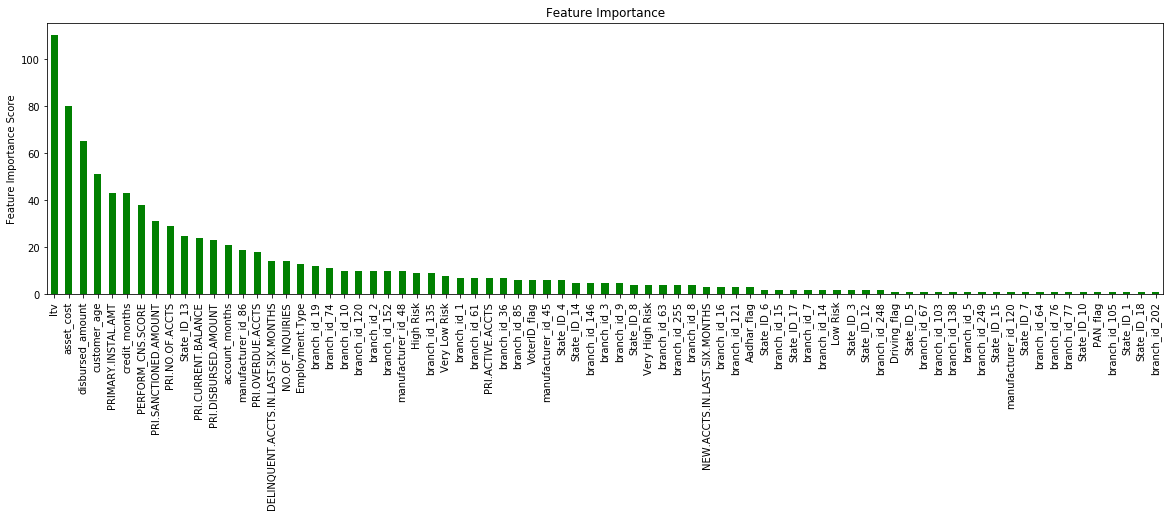

In [72]:
feat_imp = pd.Series(xgb_grid.best_estimator_.get_booster()
                     .get_score(importance_type='weight'))\
    .sort_values(ascending=False)
plt.figure(figsize=(20,5))
feat_imp.plot(kind='bar', title='Feature Importance', color='g')
plt.ylabel('Feature Importance Score')
plt.show()

In [73]:
score = cross_val_score(xgb_grid.best_estimator_,X_train, y_train, scoring='roc_auc', cv=5)
print(score)
print(f'mean: {score.mean()}')
print(f'std: {score.std()}')

[0.63297396 0.64321396 0.65736348 0.62868982 0.65073277]
mean: 0.64259479994288
std: 0.010683003064479626


Doesn't look very impressive

## In-depth parameter tuning

Based on https://dataplatform.cloud.ibm.com/exchange/public/entry/view/ac820b22cc976f5cf6487260f4c8d9c8

In [75]:
from sklearn.metrics import accuracy_score, roc_auc_score
#learning rate as a constant
L_R = 0.1

In [76]:
# initializing our first model with an objective and learning rate
xgb0 = xgb.XGBClassifier(objective='binary:logistic',
                         learning_rate = L_R)

In [95]:
def evaluate_model(alg, train, target, predictors,
                   cv_folds=5, early_stopping_rounds=5):

    xgb_param = alg.get_xgb_params()
    xgtrain = xgb.DMatrix(train[predictors].values, target.values)
    cvresult = xgb.cv(xgb_param, xgtrain,
                      num_boost_round=alg.get_params()['n_estimators'],
                      nfold=cv_folds, metrics='auc',
                      early_stopping_rounds=early_stopping_rounds,
                      verbose_eval=True)
    alg.set_params(n_estimators=cvresult.shape[0])

    # Fit the algorithm on the data
    alg.fit(train[predictors], target, eval_metric='auc',
            eval_set=[(X_test, y_test)])

    # Predict training set:
    dtrain_predictions = alg.predict(train[predictors])
    dtrain_predprob = alg.predict_proba(train[predictors])[:, 1]

    # Print model report:
    print("\nModel Report")
    print("Accuracy : %.4g" % accuracy_score(target.values,
                                             dtrain_predictions))
    print("AUC Score (Train): %f" % roc_auc_score(target, dtrain_predprob))

    feat_imp = pd.Series(alg.get_booster()
                         .get_score(importance_type='weight'))\
        .sort_values(ascending=False)
    plt.figure(figsize=(20, 5))
    feat_imp.plot(kind='bar', title='Feature Importance', color='g')
    plt.ylabel('Feature Importance Score')
    plt.show()

    return cvresult.shape[0]

### Default model

[0]	train-auc:0.607564+0.00362776	test-auc:0.595937+0.0126089
[1]	train-auc:0.616822+0.00498567	test-auc:0.603163+0.0127006
[2]	train-auc:0.62378+0.00417844	test-auc:0.608923+0.0129083
[3]	train-auc:0.628341+0.0041777	test-auc:0.613191+0.0103971
[4]	train-auc:0.632118+0.00530167	test-auc:0.615756+0.0113249
[5]	train-auc:0.633863+0.00398412	test-auc:0.617075+0.0122428
[6]	train-auc:0.635543+0.00372364	test-auc:0.618418+0.0121428
[7]	train-auc:0.637026+0.00427216	test-auc:0.618673+0.0121303
[8]	train-auc:0.638959+0.00461947	test-auc:0.61931+0.0123758
[9]	train-auc:0.641261+0.00452396	test-auc:0.620032+0.0125347
[10]	train-auc:0.642836+0.00407514	test-auc:0.620754+0.0130695
[11]	train-auc:0.644655+0.00394338	test-auc:0.62168+0.0132232
[12]	train-auc:0.645629+0.00419101	test-auc:0.621061+0.0136803
[13]	train-auc:0.647328+0.00423165	test-auc:0.622396+0.0136177
[14]	train-auc:0.648352+0.00407768	test-auc:0.623045+0.0127132
[15]	train-auc:0.649966+0.00428586	test-auc:0.623543+0.0132616
[16]	t

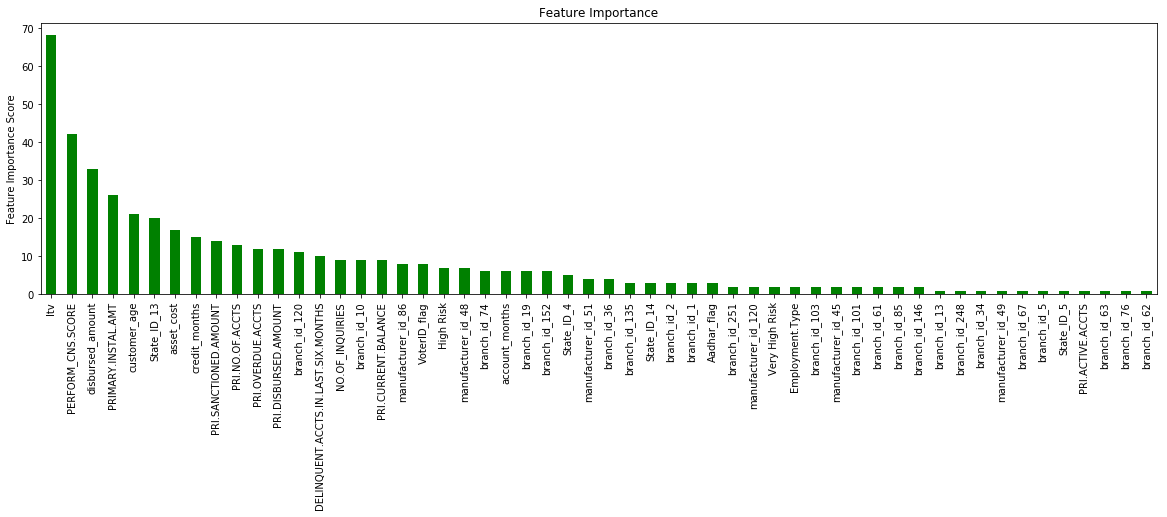

In [96]:
# a list of features to be used for training the model
features = feature_cols

# evaluating the first model
n_est = evaluate_model(xgb0, X_train,
                       y_train, features)

### Tuning max depth and child weight

In [97]:
# updating our default model with the optimal number of estimators
# i.e. the last interation of evaluate_model
xgb1 = xgb.XGBClassifier(
 objective='binary:logistic',
 learning_rate=L_R,
 n_estimators=n_est)

# array of values for max_depth and min_child_weight parameters
param_test1 = {'max_depth': range(3, 10, 1),
               'min_child_weight': range(1, 3, 1)}

# grid search with cross-validation using the updated model and parameter value array 
gsearch1 = GridSearchCV(estimator = xgb1,
                        param_grid = param_test1,
                        scoring='roc_auc', iid=False,
                        cv=5, n_jobs=-1)
gsearch1.fit(X_train[features], y_train)
gsearch1.cv_results_['params'], gsearch1.best_params_, gsearch1.best_score_

([{'max_depth': 3, 'min_child_weight': 1},
  {'max_depth': 3, 'min_child_weight': 2},
  {'max_depth': 4, 'min_child_weight': 1},
  {'max_depth': 4, 'min_child_weight': 2},
  {'max_depth': 5, 'min_child_weight': 1},
  {'max_depth': 5, 'min_child_weight': 2},
  {'max_depth': 6, 'min_child_weight': 1},
  {'max_depth': 6, 'min_child_weight': 2},
  {'max_depth': 7, 'min_child_weight': 1},
  {'max_depth': 7, 'min_child_weight': 2},
  {'max_depth': 8, 'min_child_weight': 1},
  {'max_depth': 8, 'min_child_weight': 2},
  {'max_depth': 9, 'min_child_weight': 1},
  {'max_depth': 9, 'min_child_weight': 2}],
 {'max_depth': 4, 'min_child_weight': 2},
 0.6400733431401928)

In [98]:
param0 = gsearch1.best_params_

### Tuning gamma

In [99]:
# updating our current model with the max_depth and min_child weight
# parameter values found in last grid search

xgb2 = xgb.XGBClassifier(objective='binary:logistic',
                         learning_rate =L_R,
                         n_estimators=n_est,
                         **param0, gamma=0)

# array of values for the gamma parameter
gamma_test = {'gamma': np.arange(0, 0.06, 0.01)}

# grid search with cross-validation using the updated model and gamma value array 
gsearch2 = GridSearchCV(estimator = xgb2, param_grid = gamma_test,
                        scoring='roc_auc', iid=False, cv=5, n_jobs=-1)
gsearch2.fit(X_train[features], y_train)
gsearch2.cv_results_['params'], gsearch2.best_params_, gsearch2.best_score_

([{'gamma': 0.0},
  {'gamma': 0.01},
  {'gamma': 0.02},
  {'gamma': 0.03},
  {'gamma': 0.04},
  {'gamma': 0.05}],
 {'gamma': 0.01},
 0.6400740420743183)

In [100]:
param1 = gsearch2.best_params_

### Evaluating the updated model

[0]	train-auc:0.625236+0.00340081	test-auc:0.606867+0.00979446
[1]	train-auc:0.635989+0.00411441	test-auc:0.614169+0.00816553
[2]	train-auc:0.641664+0.00285256	test-auc:0.619438+0.0105774
[3]	train-auc:0.643751+0.00442914	test-auc:0.61987+0.00928678
[4]	train-auc:0.648536+0.00417493	test-auc:0.620395+0.0114419
[5]	train-auc:0.65115+0.00430733	test-auc:0.621637+0.0123965
[6]	train-auc:0.654259+0.00524706	test-auc:0.622108+0.0125637
[7]	train-auc:0.65605+0.00475658	test-auc:0.622685+0.0124822
[8]	train-auc:0.658313+0.00480837	test-auc:0.623888+0.0121665
[9]	train-auc:0.660428+0.00407051	test-auc:0.624871+0.0132737
[10]	train-auc:0.662855+0.00325126	test-auc:0.62638+0.0138915
[11]	train-auc:0.665544+0.00391327	test-auc:0.626301+0.0142651
[12]	train-auc:0.66701+0.00368036	test-auc:0.627284+0.0143903
[13]	train-auc:0.669054+0.00381448	test-auc:0.627467+0.0140291
[14]	train-auc:0.670949+0.0039133	test-auc:0.62793+0.0133224
[15]	train-auc:0.672641+0.00417973	test-auc:0.628269+0.0130059
[16]	t

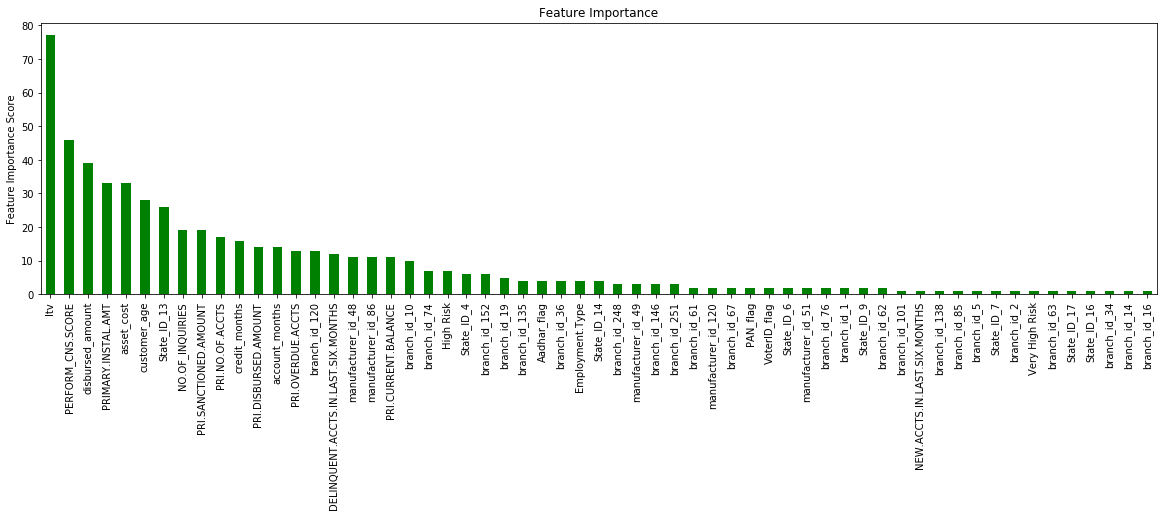

In [101]:
xgb_check = xgb.XGBClassifier(objective='binary:logistic',
                              learning_rate=L_R,
                              **param0, **param1)

n_est1 = evaluate_model(xgb_check, X_train, y_train, features)

### Tuning sampling parameters

In [102]:
# updating our current model with the most recent n_estimators
xgb3 = xgb.XGBClassifier(objective='binary:logistic',
                         learning_rate=L_R,
                         n_estimators=n_est1,
                         **param0, **param1)

# array of values for subsample and colsample_bytree parameters
sample_test = {'subsample': np.arange(0.5, 1, 0.1),
               'colsample_bytree': np.arange(0.6, 1, 0.1)}

# grid search with cross validation for sampling parameters
gsearch3 = GridSearchCV(estimator = xgb3, param_grid = sample_test,
                        scoring='roc_auc', iid=False, cv=5, n_jobs=-1)
gsearch3.fit(X_train[features], y_train)
gsearch3.cv_results_['params'], gsearch3.best_params_, gsearch3.best_score_

([{'colsample_bytree': 0.6, 'subsample': 0.5},
  {'colsample_bytree': 0.6, 'subsample': 0.6},
  {'colsample_bytree': 0.6, 'subsample': 0.7},
  {'colsample_bytree': 0.6, 'subsample': 0.7999999999999999},
  {'colsample_bytree': 0.6, 'subsample': 0.8999999999999999},
  {'colsample_bytree': 0.7, 'subsample': 0.5},
  {'colsample_bytree': 0.7, 'subsample': 0.6},
  {'colsample_bytree': 0.7, 'subsample': 0.7},
  {'colsample_bytree': 0.7, 'subsample': 0.7999999999999999},
  {'colsample_bytree': 0.7, 'subsample': 0.8999999999999999},
  {'colsample_bytree': 0.7999999999999999, 'subsample': 0.5},
  {'colsample_bytree': 0.7999999999999999, 'subsample': 0.6},
  {'colsample_bytree': 0.7999999999999999, 'subsample': 0.7},
  {'colsample_bytree': 0.7999999999999999, 'subsample': 0.7999999999999999},
  {'colsample_bytree': 0.7999999999999999, 'subsample': 0.8999999999999999},
  {'colsample_bytree': 0.8999999999999999, 'subsample': 0.5},
  {'colsample_bytree': 0.8999999999999999, 'subsample': 0.6},
  {'co

In [103]:
param2 = gsearch3.best_params_

### Tuning alpha and lambda

In [104]:
# updating our current model with the sampling parameters found in the last grid search
xgb4 = xgb.XGBClassifier(objective='binary:logistic',
                         learning_rate=L_R,
                         n_estimators=n_est1,
                         **param0, **param1,
                         **param2)

reg_test = {'reg_alpha': [0, 0.01, 0.1],
            'reg_lambda': np.arange(1, 1.6, 0.1)}

# grid search with cross validation for regularization parameters
gsearch4 = GridSearchCV(estimator = xgb4, param_grid = reg_test,
                        scoring='roc_auc', iid=False, cv=5, n_jobs=-1)

gsearch4.fit(X_train[features], y_train)
gsearch4.cv_results_['params'], gsearch4.best_params_, gsearch4.best_score_

([{'reg_alpha': 0, 'reg_lambda': 1.0},
  {'reg_alpha': 0, 'reg_lambda': 1.1},
  {'reg_alpha': 0, 'reg_lambda': 1.2000000000000002},
  {'reg_alpha': 0, 'reg_lambda': 1.3000000000000003},
  {'reg_alpha': 0, 'reg_lambda': 1.4000000000000004},
  {'reg_alpha': 0, 'reg_lambda': 1.5000000000000004},
  {'reg_alpha': 0, 'reg_lambda': 1.6000000000000005},
  {'reg_alpha': 0.01, 'reg_lambda': 1.0},
  {'reg_alpha': 0.01, 'reg_lambda': 1.1},
  {'reg_alpha': 0.01, 'reg_lambda': 1.2000000000000002},
  {'reg_alpha': 0.01, 'reg_lambda': 1.3000000000000003},
  {'reg_alpha': 0.01, 'reg_lambda': 1.4000000000000004},
  {'reg_alpha': 0.01, 'reg_lambda': 1.5000000000000004},
  {'reg_alpha': 0.01, 'reg_lambda': 1.6000000000000005},
  {'reg_alpha': 0.1, 'reg_lambda': 1.0},
  {'reg_alpha': 0.1, 'reg_lambda': 1.1},
  {'reg_alpha': 0.1, 'reg_lambda': 1.2000000000000002},
  {'reg_alpha': 0.1, 'reg_lambda': 1.3000000000000003},
  {'reg_alpha': 0.1, 'reg_lambda': 1.4000000000000004},
  {'reg_alpha': 0.1, 'reg_lambda'

In [105]:
param3 = gsearch4.best_params_

[0]	train-auc:0.621683+0.00631896	test-auc:0.599272+0.0158747
[1]	train-auc:0.634851+0.00428306	test-auc:0.611057+0.0150068
[2]	train-auc:0.642502+0.00462386	test-auc:0.614213+0.0126291
[3]	train-auc:0.646882+0.00548778	test-auc:0.617893+0.013617
[4]	train-auc:0.650832+0.00443654	test-auc:0.620053+0.013918
[5]	train-auc:0.653569+0.00361476	test-auc:0.622311+0.0138128
[6]	train-auc:0.656517+0.00262767	test-auc:0.624214+0.01536
[7]	train-auc:0.659663+0.0020077	test-auc:0.625597+0.0137456
[8]	train-auc:0.661128+0.00161164	test-auc:0.626325+0.0136091
[9]	train-auc:0.66291+0.00170053	test-auc:0.627594+0.0136451
[10]	train-auc:0.665721+0.0013931	test-auc:0.627951+0.0138662
[11]	train-auc:0.66746+0.00115297	test-auc:0.628374+0.014969
[12]	train-auc:0.668648+0.000963943	test-auc:0.628706+0.0148004
[13]	train-auc:0.670309+0.00127886	test-auc:0.629354+0.0159594
[14]	train-auc:0.671665+0.00184184	test-auc:0.629827+0.0161319
[15]	train-auc:0.673002+0.00167769	test-auc:0.63018+0.0158493
[16]	train-

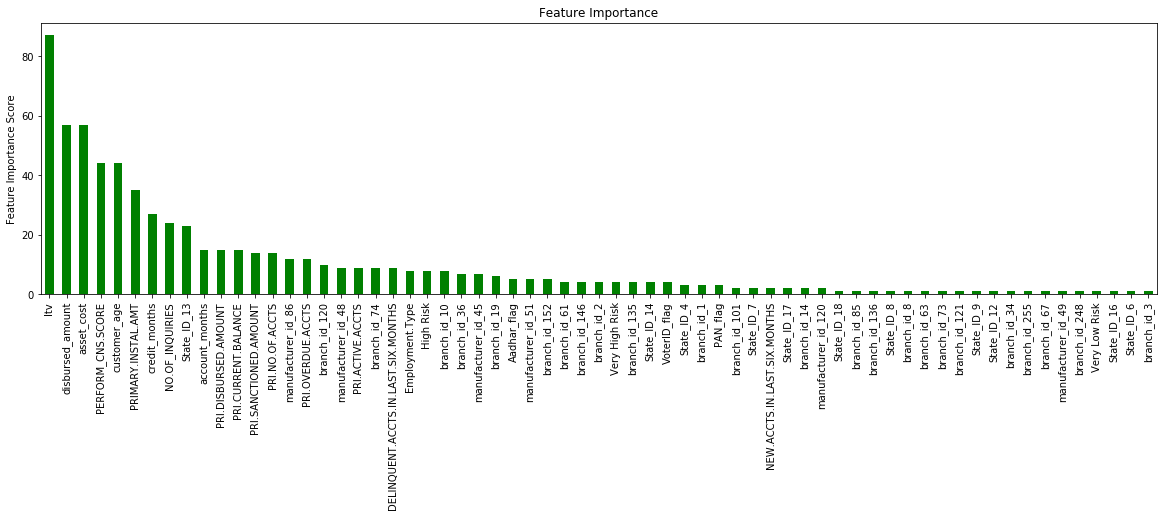

49

In [106]:
# updated model with alpha value found with last grid search

xgb_final = xgb.XGBClassifier(objective='binary:logistic',
                              learning_rate=L_R,
                              **param0, **param1,
                              **param2, **param3)

evaluate_model(xgb_final, X_train, y_train, features)

### Some final scores

In [107]:
#Predict test set:
test_predictions = xgb_final.predict(X_train)
test_predprob = xgb_final.predict_proba(X_train)[:, 1]

#Print model report:
print("Train Accuracy : %.4g" % accuracy_score(y_train, test_predictions))
print("AUC Score (Train): %f" % roc_auc_score(y_train, test_predprob))

Train Accuracy : 0.777
AUC Score (Train): 0.704214


In [108]:
test_predictions = xgb_final.predict(X_test)
test_predprob = xgb_final.predict_proba(X_test)[:, 1]
print("Accuracy : %.4g" % accuracy_score(y_test, test_predictions))
print("AUC Score (Test): %f" % roc_auc_score(y_test, test_predprob))

Accuracy : 0.7872
AUC Score (Test): 0.646866


### Same but with the default regularization parameters

In [109]:
test_predictions = xgb_check.predict(X_train)
test_predprob = xgb_check.predict_proba(X_train)[:, 1]
print("Train Accuracy : %.4g" % accuracy_score(y_train, test_predictions))
print("AUC Score (Train): %f" % roc_auc_score(y_train, test_predprob))

Train Accuracy : 0.7756
AUC Score (Train): 0.698526


In [110]:
test_predictions = xgb_check.predict(X_test)
test_predprob = xgb_check.predict_proba(X_test)[:, 1]
print("Test Accuracy : %.4g" % accuracy_score(y_test, test_predictions))
print("AUC Score (Test): %f" % roc_auc_score(y_test, test_predprob))

Test Accuracy : 0.7875
AUC Score (Test): 0.643036


Looks like the overall performance is somewhat better with the default regularization parameters

### Comparing the AUC curves

In [111]:
from sklearn.metrics import roc_auc_score, roc_curve,auc
from sklearn import metrics
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from scipy import interp

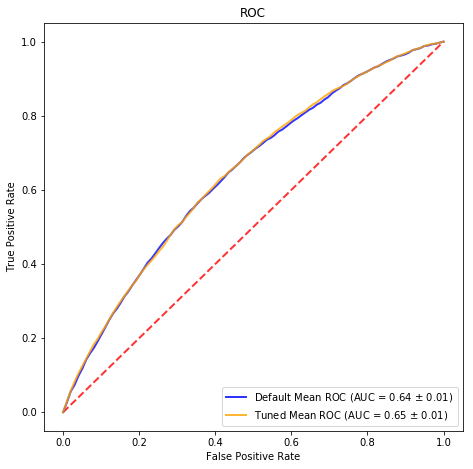

In [112]:
X, y = df[features].to_numpy(), df['loan_default'].to_numpy()

roc_curve_plot(X, y, xgb0, xgb_final)

Tuned variant is sliiiightly better (inside the margin of error, though)

## Results submission

In [113]:
def preprocess(df):
    df['birth_year'] = (df['Date.of.Birth'].str.split('-').str[-1]).astype(int)
    df['birth_year'] = (df['birth_year'] > 40) * (df['birth_year'] + 1900) + \
        (df['birth_year'] < 40) * (df['birth_year'] + 2000)
    df['disb_year'] = (df['DisbursalDate'].str.split('-').str[-1]).astype(int)
    df['disb_year'] = (df['disb_year'] > 40) * (df['disb_year'] + 1900) + \
        (df['disb_year'] < 40) * (df['disb_year'] + 2000)
    df['customer_age'] = df['disb_year'] - df['birth_year']

    df = df.drop(['Date.of.Birth', 'DisbursalDate', 'birth_year',
                  'disb_year'], axis=1)

    df['Employment.Type'] = (df['Employment.Type'] == 'Salaried')

    df.loc[df['PERFORM_CNS.SCORE.DESCRIPTION']
           .str.contains('|'.join(['Not Scored', 'No Bureau'])),
           'PERFORM_CNS.SCORE.DESCRIPTION'] = ''
    riskvals = ['Very Low Risk', 'Low Risk', 'Medium Risk',
                'High Risk', 'Very High Risk']
    for r in riskvals:
        df[r] = df['PERFORM_CNS.SCORE.DESCRIPTION'].str.contains(r)

    df['account_months'] = (df['AVERAGE.ACCT.AGE'].str.split('yrs')
                            .str[0]).astype(int) * 12 + \
        df['AVERAGE.ACCT.AGE'].str.split('yrs').str[1]\
        .str.split('mon').str[0].astype(int)
    df['credit_months'] = (df['CREDIT.HISTORY.LENGTH'].str.split('yrs')
                           .str[0]).astype(int) * 12 + \
        df['CREDIT.HISTORY.LENGTH'].str.split('yrs').str[1]\
        .str.split('mon').str[0].astype(int)

    df = df.drop(df.dtypes[df.dtypes == 'object'].index, axis=1)

    df = df.drop(['supplier_id', 'Current_pincode_ID', 'Employee_code_ID'],
                 axis=1)

    df = pd.get_dummies(df, columns=['manufacturer_id', 'branch_id',
                                     'State_ID'])

    filtered_df = filter_data(df, istrain=False)

    return filtered_df

In [114]:
test_df = pd.read_csv('data/test.csv')

In [115]:
proc_test = preprocess(test_df)

In [116]:
diff = set(filtered_df.columns[filtered_df.columns != 'loan_default']) -\
    set(proc_test.columns)

In [117]:
for c in diff:
    proc_test[c] = [0] * proc_test.shape[0]

[0]	train-auc:0.621683+0.00631896	test-auc:0.599272+0.0158747
[1]	train-auc:0.634851+0.00428306	test-auc:0.611057+0.0150068
[2]	train-auc:0.642502+0.00462386	test-auc:0.614213+0.0126291
[3]	train-auc:0.646882+0.00548778	test-auc:0.617893+0.013617
[4]	train-auc:0.650832+0.00443654	test-auc:0.620053+0.013918
[5]	train-auc:0.653569+0.00361476	test-auc:0.622311+0.0138128
[6]	train-auc:0.656517+0.00262767	test-auc:0.624214+0.01536
[7]	train-auc:0.659663+0.0020077	test-auc:0.625597+0.0137456
[8]	train-auc:0.661128+0.00161164	test-auc:0.626325+0.0136091
[9]	train-auc:0.66291+0.00170053	test-auc:0.627594+0.0136451
[10]	train-auc:0.665721+0.0013931	test-auc:0.627951+0.0138662
[11]	train-auc:0.66746+0.00115297	test-auc:0.628374+0.014969
[12]	train-auc:0.668648+0.000963943	test-auc:0.628706+0.0148004
[13]	train-auc:0.670309+0.00127886	test-auc:0.629354+0.0159594
[14]	train-auc:0.671665+0.00184184	test-auc:0.629827+0.0161319
[15]	train-auc:0.673002+0.00167769	test-auc:0.63018+0.0158493
[16]	train-

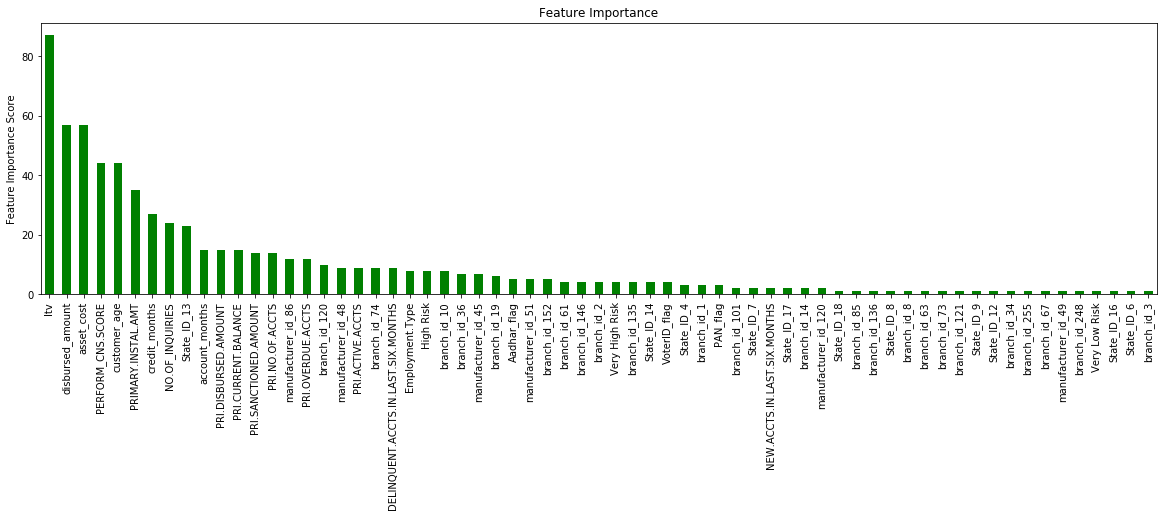

49

In [118]:
# if it throws an arror about the features mismatch
evaluate_model(xgb_final, X_train, y_train, features)

In [119]:
y_pred = xgb_final.predict_proba(proc_test[features])[:, 1]

sub_df = pd.concat([proc_test['UniqueID'],
                    pd.Series(y_pred)], axis=1,
                   ignore_index=True)

sub_df.columns = ['UniqueID','loan_default']

In [120]:
sub_df.head()

,UniqueID,loan_default
0,535191,0.189977
1,565698,0.141201
2,536003,0.180882
3,628720,0.132267
4,627276,0.141506


In [121]:
sub_df = sub_df.set_index('UniqueID')

In [122]:
sub_df.to_csv('data/predicted.csv')